# 03 — Re-estimación econométrica Sprint 13B

## Sprint 13B — Advanced Data Expansion

### Objetivo

Este notebook evalúa si las nuevas features avanzadas derivadas de FBref mejoran la capacidad explicativa del benchmark econométrico de valoración de mercado.

La comparación principal es:

```text
Modelo A — especificación v13A
vs
Modelo B — especificación v13A + advanced FBref features
```

Nuevas features evaluadas:

- `finishing_index_v2`
- `availability_index`
- `defensive_activity_index`

El objetivo no es sustituir al modelo productivo de Machine Learning, sino evaluar la contribución incremental de las nuevas variables en un marco econométrico interpretable.

## 1. Objetivo analítico y decisión de negocio

El objetivo econométrico es estimar el valor de mercado esperado de un jugador a partir de:

- edad;
- volumen competitivo;
- producción ofensiva;
- contexto de liga;
- posición;
- variables históricas de rendimiento;
- nuevas métricas avanzadas de FBref.

Desde el punto de vista de negocio, el objetivo no es únicamente minimizar error predictivo, sino determinar si las nuevas señales de rendimiento permiten explicar mejor las valoraciones de mercado.

La contribución metodológica de Sprint 13B consiste en evaluar si la expansión del espacio de variables aporta información adicional respecto a la especificación v13A.

## 2. Especificación econométrica

La especificación base v13A estima:

```python
log_market_value_eur ~
age +
log_minutes_played +
goals_per90 +
assists_per90 +
existing composite indices +
league FE +
position FE
```

Sprint 13B evalúa una especificación extendida:

```python
log_market_value_eur ~
base specification +
finishing_index_v2 +
availability_index +
defensive_activity_index
```

Decisiones metodológicas:

- se mantiene `log_market_value_eur` como target principal;
- se utilizan efectos fijos de liga y posición;
- se evita usar efectos fijos de temporada en el modelo predictivo final;
- la evaluación se realiza con validación temporal estricta;
- Modelo A y Modelo B se estiman sobre la misma muestra efectiva para que la comparación sea limpia.

In [1]:
# ============================================================
# 1. Imports y configuración
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

TARGET = "log_market_value_eur"
RANDOM_STATE = 42

TRAIN_SEASONS = [
    "2019-2020",
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]

TEST_SEASON = "2024-2025"
CURRENT_SCOUTING_SEASON = "2025-2026"


In [2]:
# ============================================================
# 2. Rutas del proyecto
# ============================================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "player_season_modeling_v13b_advanced.parquet"
OUTPUT_DIR = PROJECT_ROOT / "reports" / "sprint_13b" / "econometric"
MODEL_OUTPUT_DIR = OUTPUT_DIR / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "sprint_13b" / "econometric"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

PROJECT_ROOT: c:\Users\manue\Projects\market-value-football-tfm
DATA_PATH: c:\Users\manue\Projects\market-value-football-tfm\data\processed\player_season_modeling_v13b_advanced.parquet
OUTPUT_DIR: c:\Users\manue\Projects\market-value-football-tfm\reports\sprint_13b\econometric


## 3. Carga y validación del dataset modelizable

El dataset modelizable procede de:

```text
data/processed/player_season_modeling_v13a.parquet
```

En el Sprint 13A.1 — Multi-League Modeling Evaluation debe contener la cobertura completa:

```text
2019-2020 → 2025-2026 | 11 ligas | 5.527 observaciones | 2.867 jugadores
```

Este notebook utiliza únicamente las temporadas históricas para la validación econométrica y deja 2025-2026 fuera del entrenamiento/test, al pertenecer a la Current Scouting Layer.


In [3]:
# ============================================================
# 3. Carga del dataset
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No existe {DATA_PATH}. Ejecuta antes src.data.build_modeling_dataset."
    )

df = pd.read_parquet(DATA_PATH)

print("Dataset cargado")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Players: {df['player_name_fbref'].nunique() if 'player_name_fbref' in df.columns else 'n/a'}")
print(f"Seasons: {df['season'].min()} - {df['season'].max()}")
df.head()

Dataset cargado
Rows: 5,527
Columns: 78
Players: 2867
Seasons: 2019-2020 - 2025-2026


,player_name_fbref,club,league,season,season_start_year_fbref,position,position_group,age_fbref,matches_played,starts,minutes_played,nineties,goals,assists,g_a,goals_minus_pk,penalties_scored,penalties_attempted,yellow_cards,red_cards,goals_per90,assists_per90,g_a_per90,goals_minus_pk_per90,g_a_minus_pk_per90,player_name_norm,player_id_tm,player_name_tm,season_start_year_tm,valuation_date,market_value_eur,log_market_value_eur,market_value_prev_eur,market_value_next_eur,market_value_growth_1y,delta_log_market_value_1y,age_tm,date_of_birth,nationality,position_tm,sub_position_tm,foot,height_in_cm,current_club_name_tm,current_club_id_tm,competition_id_tm,source,matching_method,matching_confidence,age_diff,club_score,matching_status,season_start_year,age,player_name_normalized,adv_goals,adv_shots,adv_shots_on_target,adv_shots_per90,adv_shots_on_target_per90,adv_minutes,adv_starts,adv_complete_matches,adv_interceptions,adv_tackles_won,goals_position_pct,shots_position_pct,shots_on_target_position_pct,shots_per90_position_pct,shots_on_target_per90_position_pct,starts_position_pct,minutes_position_pct,complete_matches_position_pct,interceptions_position_pct,tackles_won_position_pct,finishing_index_v2,availability_index,defensive_activity_index
0,Marvin Young,Sparta Rotterdam,Eredivisie,2025-2026,2025,DF,DEF,19.0000,33,33,2970,33.0000,0,1,1,0,0,0,7,0,0.0000,0.0300,0.0300,0.0000,0.0300,marvin young,"928,592.0000",Marvin Young,"2,025.0000",2025-10-02,"4,000,000.0000",15.2018,"2,500,000.0000","4,000,000.0000",0.0000,0.0000,20.0000,2005-10-02 00:00:00,Netherlands,Defender,Centre-Back,right,182.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.0000,100.0000,True,2025,20.0000,marvin young,0,10,1,0.3000,0.0300,2970,33,33,55,39,0.2424,0.4394,0.2576,0.0909,0.1970,0.9091,0.9394,0.9697,0.9394,0.9091,0.2652,0.9364,0.9242
1,Tyrese Campbell,Stoke City,Championship,2022-2023,2022,"FW,MF",MID,22.0000,41,30,2656,29.5000,9,5,14,9,0,0,4,0,0.3000,0.1700,0.4700,0.3000,0.4700,tyrese campbell,"382,554.0000",Tyrese Campbell,"2,022.0000",2022-09-14,"3,000,000.0000",14.9141,"4,000,000.0000","3,000,000.0000",0.0000,0.0000,22.7132,1999-12-28 00:00:00,England,Attack,Centre-Forward,left,185.0000,Stoke City,512.0000,GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.7132,100.0000,True,2022,22.7132,tyrese campbell,9,83,38,2.8100,1.2900,2656,30,15,16,12,0.9123,0.9386,0.9123,0.8421,0.8947,0.7807,0.8772,0.7544,0.6404,0.3596,0.9088,0.8018,0.5000
2,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2022-2023,2022,MF,MID,20.0000,34,29,2651,29.5000,4,2,6,4,0,0,2,0,0.1400,0.0700,0.2000,0.1400,0.2000,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,022.0000",2022-11-11,"1,200,000.0000",13.9978,"800,000.0000","3,000,000.0000",1.5000,0.9163,21.2731,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2731,100.0000,True,2022,21.2731,joshua kitolano,4,37,14,1.2600,0.4800,2651,29,25,27,35,0.7453,0.7170,0.6698,0.2358,0.3019,0.8302,0.9245,0.9340,0.8868,0.9245,0.6292,0.8896,0.9057
3,Teden Mengi,Luton Town,Premier League,2023-2024,2023,DF,DEF,21.0000,30,28,2469,27.4000,1,0,1,1,0,0,3,0,0.0400,0.0000,0.0400,0.0400,0.0400,teden mengi,"548,470.0000",Teden Mengi,"2,023.0000",2023-12-19,"7,000,000.0000",15.7614,"2,000,000.0000","12,000,000.0000",0.7143,0.5390,21.6372,2002-04-30 00:00:00,England,Defender,Centre-Back,right,186.0000,Luton Town,"1,031.0000",GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.6372,100.0000,True,2023,21.6372,teden mengi,1,11,4,0.4000,0.1500,2469,28,25,54,22,0.6129,0.6452,0.6290,0.3548,0.5000,0.8226,0.8710,0.8710,1.0000,0.5000,0.5855,0.8516,0.7500
4,Harry Clarke,Ipswich Town,Championship,2023-2024,2023,DF,DEF,22.0000,35,25,2361,26.2000,1,1,2,1,0,0,7,0,0.0400,0.0400,0.0800,0.0400,0.0800,harry clarke,"528,892.0000",Harry Clarke,"2,023.0000",2023-12-21,"2,500,000

In [4]:
print("Dataset cargado")
print(f"Rows: {len(df):,}")
print(f"Players: {df['player_id_tm'].nunique():,}")
print(f"Leagues: {df['league'].nunique():,}")
print(f"Seasons: {df['season'].nunique():,}")
print(sorted(df["league"].dropna().unique()))

Dataset cargado
Rows: 5,527
Players: 2,867
Leagues: 11
Seasons: 7
['Austrian Bundesliga', 'Belgian Pro League', 'Bundesliga', 'Championship', 'Eredivisie', 'LaLiga', 'Liga Portugal', 'Ligue 1', 'Premier League', 'Serie A', 'Spanish Segunda División']


In [5]:
# ============================================================
# 4. Normalización de columnas auxiliares
# ============================================================

model_df = df.copy()

# Nombre de jugador para rankings
if "player_name" not in model_df.columns:
    if "player_name_fbref" in model_df.columns:
        model_df["player_name"] = model_df["player_name_fbref"]
    elif "player_name_tm" in model_df.columns:
        model_df["player_name"] = model_df["player_name_tm"]

# Edad consolidada
if "age" not in model_df.columns:
    if "age_tm" in model_df.columns:
        model_df["age"] = model_df["age_tm"]
    elif "age_fbref" in model_df.columns:
        model_df["age"] = model_df["age_fbref"]

# Log de minutos
if "minutes_played" not in model_df.columns:
    raise KeyError("Falta minutes_played, variable mínima para el modelo.")

model_df["log_minutes_played"] = np.log1p(model_df["minutes_played"])

required = [TARGET, "market_value_eur", "season", "league", "position_group", "age", "log_minutes_played"]
missing = [c for c in required if c not in model_df.columns]
if missing:
    raise KeyError(f"Faltan columnas obligatorias: {missing}")

print("Columnas mínimas validadas correctamente")

Columnas mínimas validadas correctamente


## 4. Feature engineering deportivo

Se incorporan variables deportivas disponibles en el dataset. Cuando existen métricas suficientes, se construyen índices normalizados por `position_group` y `league` para mejorar comparabilidad entre roles y contextos competitivos.

La lógica es conservadora: no se fuerza ninguna variable inexistente. El notebook detecta columnas disponibles y ajusta la especificación final automáticamente.

In [6]:
# ============================================================
# 5. Feature engineering robusto según columnas disponibles
# ============================================================

PERFORMANCE_CANDIDATES = [
    "goals_per90",
    "assists_per90",
    "shots_per90",
    "progressive_passes_per90",
    "progressive_carries_per90",
    "tackles_per90",
    "interceptions_per90",
]

available_perf = [c for c in PERFORMANCE_CANDIDATES if c in model_df.columns]
print("Variables deportivas disponibles:", available_perf)

for col in available_perf:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")


def safe_zscore(s: pd.Series) -> pd.Series:
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / std


# Z-scores por posición y liga para controlar comparabilidad contextual
for col in available_perf:
    z_col = f"z_{col}"
    model_df[z_col] = (
        model_df
        .groupby(["position_group", "league"], dropna=False)[col]
        .transform(safe_zscore)
    )


# Índices interpretables heredados de versiones anteriores, solo si existen los componentes necesarios
if {"z_goals_per90", "z_shots_per90"}.issubset(model_df.columns):
    model_df["finishing_index"] = model_df[["z_goals_per90", "z_shots_per90"]].mean(axis=1)

if {"z_assists_per90", "z_progressive_passes_per90"}.issubset(model_df.columns):
    model_df["playmaking_index"] = model_df[["z_assists_per90", "z_progressive_passes_per90"]].mean(axis=1)

if {"z_progressive_passes_per90", "z_progressive_carries_per90"}.issubset(model_df.columns):
    model_df["progression_index"] = model_df[["z_progressive_passes_per90", "z_progressive_carries_per90"]].mean(axis=1)

if {"z_tackles_per90", "z_interceptions_per90"}.issubset(model_df.columns):
    model_df["defensive_index"] = model_df[["z_tackles_per90", "z_interceptions_per90"]].mean(axis=1)

created_indexes = [
    c for c in ["finishing_index", "playmaking_index", "progression_index", "defensive_index"]
    if c in model_df.columns
]

ADVANCED_13B_FEATURES = [
    c for c in [
        "finishing_index_v2",
        "availability_index",
        "defensive_activity_index",
    ]
    if c in model_df.columns
]

for col in ADVANCED_13B_FEATURES:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

print("Índices heredados disponibles:", created_indexes)
print("Features Sprint 13B disponibles:", ADVANCED_13B_FEATURES)

if ADVANCED_13B_FEATURES:
    advanced_corr = model_df[ADVANCED_13B_FEATURES].corr()
    advanced_corr.to_csv(OUTPUT_DIR / "correlation_advanced_features.csv")
    display(advanced_corr)

Variables deportivas disponibles: ['goals_per90', 'assists_per90']
Índices heredados disponibles: []
Features Sprint 13B disponibles: ['finishing_index_v2', 'availability_index', 'defensive_activity_index']


,finishing_index_v2,availability_index,defensive_activity_index
finishing_index_v2,1.0000,0.5234,0.3302
availability_index,0.5234,1.0000,0.7930
defensive_activity_index,0.3302,0.7930,1.0000


## 5.1 Nota metodológica sobre features avanzadas

Sprint 13B incorpora tres índices derivados de FBref avanzado:

- `finishing_index_v2`
- `availability_index`
- `defensive_activity_index`

Estos índices fueron diseñados antes de la reestimación para evitar selección oportunista de variables.  
Su construcción se basa en percentiles normalizados por posición, lo que permite mejorar la comparabilidad entre perfiles deportivos.

Las tablas FBref explotadas de forma reproducible son:

- Shooting
- Playing Time
- Miscellaneous

Las tablas Passing, Possession, GCA y Defense se mantienen como línea futura porque no están expuestas de forma estable por la vía de extracción seleccionada.

## 5. Split temporal train/test

In [7]:
# ============================================================
# 6. Muestra econométrica y split temporal
# ============================================================

BASE_NUMERIC_FEATURES = [
    "age",
    "log_minutes_played",
]

# Mantener producción ofensiva directa si está disponible
for c in ["goals_per90", "assists_per90"]:
    if c in model_df.columns:
        BASE_NUMERIC_FEATURES.append(c)

# Índices existentes en v13A
V13A_COMPOSITE_FEATURES = [
    c for c in ["finishing_index", "playmaking_index", "progression_index", "defensive_index"]
    if c in model_df.columns
]

# Modelo A: especificación v13A
MODEL_A_NUMERIC_FEATURES = BASE_NUMERIC_FEATURES + V13A_COMPOSITE_FEATURES

# Modelo B: especificación v13A + nuevas advanced FBref features
MODEL_B_NUMERIC_FEATURES = MODEL_A_NUMERIC_FEATURES + ADVANCED_13B_FEATURES

# Alias para compatibilidad con celdas posteriores: el modelo final será el Modelo B
FINAL_NUMERIC_FEATURES = MODEL_B_NUMERIC_FEATURES

# En el modelo predictivo final se evitan season fixed effects porque
# una temporada futura no está observada durante el entrenamiento.
CATEGORICAL_FEATURES = ["league", "position_group"]

needed = (
    [TARGET, "market_value_eur", "season"]
    + MODEL_B_NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
)

model_df = model_df.dropna(subset=needed).copy()

train = model_df[model_df["season"].isin(TRAIN_SEASONS)].copy()
test = model_df[model_df["season"] == TEST_SEASON].copy()
current_scouting = model_df[model_df["season"] == CURRENT_SCOUTING_SEASON].copy()

if train.empty or test.empty:
    raise ValueError("El split temporal ha generado train o test vacío. Revisa las etiquetas de temporada.")

print("Modelo A — features v13A:", MODEL_A_NUMERIC_FEATURES)
print("Modelo B — features v13B:", MODEL_B_NUMERIC_FEATURES)
print("Nuevas features Sprint 13B:", ADVANCED_13B_FEATURES)

print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Current scouting rows: {len(current_scouting):,}")

print("Train seasons:", sorted(train["season"].unique()))
print("Test seasons:", sorted(test["season"].unique()))
print("Current scouting season:", sorted(current_scouting["season"].unique()))

Modelo A — features v13A: ['age', 'log_minutes_played', 'goals_per90', 'assists_per90']
Modelo B — features v13B: ['age', 'log_minutes_played', 'goals_per90', 'assists_per90', 'finishing_index_v2', 'availability_index', 'defensive_activity_index']
Nuevas features Sprint 13B: ['finishing_index_v2', 'availability_index', 'defensive_activity_index']
Train rows: 3,854
Test rows: 776
Current scouting rows: 810
Train seasons: ['2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024']
Test seasons: ['2024-2025']
Current scouting season: ['2025-2026']


In [8]:
# Descriptivo de la muestra final
summary_sample = pd.DataFrame({
    "rows": [len(model_df)],
    "players": [model_df["player_name"].nunique() if "player_name" in model_df.columns else np.nan],
    "train_rows": [len(train)],
    "test_rows": [len(test)],
    "n_leagues": [model_df["league"].nunique()],
    "n_seasons": [model_df["season"].nunique()],
})
summary_sample

,rows,players,train_rows,test_rows,n_leagues,n_seasons
0,5440,2824,3854,776,11,7


## 6. Funciones de modelización y evaluación

Se construyen matrices de diseño consistentes entre train y test. Las dummies del test se alinean con las columnas del train para evitar errores cuando alguna categoría no aparece en una partición.

In [9]:
# ============================================================
# 7. Funciones auxiliares
# ============================================================

def build_X(data: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]) -> pd.DataFrame:
    X = data[numeric_features + categorical_features].copy()
    X = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=float)
    X = sm.add_constant(X, has_constant="add")
    return X.astype(float)


def align_X(X_new: pd.DataFrame, X_train: pd.DataFrame) -> pd.DataFrame:
    return X_new.reindex(columns=X_train.columns, fill_value=0.0).astype(float)


def fit_ols_hc3(train_df: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]):
    X_train = build_X(train_df, numeric_features, categorical_features)
    y_train = train_df[TARGET].astype(float)
    fitted = sm.OLS(y_train, X_train).fit(cov_type="HC3")
    return fitted, X_train


def predict_with_design(fitted, data: pd.DataFrame, X_train: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]) -> np.ndarray:
    X_new = build_X(data, numeric_features, categorical_features)
    X_new = align_X(X_new, X_train)
    return fitted.predict(X_new)


def regression_metrics(y_true, y_pred, model_name: str, split: str) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "model": model_name,
        "split": split,
        "n": len(y_true),
        "MAE_log": mean_absolute_error(y_true, y_pred),
        "RMSE_log": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
    }

## 7. Modelos estimados

Se estiman tres modelos:

- **M0 — Media de train**: benchmark ingenuo.
- **Modelo A — v13A base specification + FE**: especificación econométrica previa.
- **Modelo B — v13B advanced features + FE**: Modelo A extendido con `finishing_index_v2`, `availability_index` y `defensive_activity_index`.

La comparación A/B permite medir la contribución incremental de las nuevas variables FBref avanzadas.

In [10]:
# ============================================================
# 8. Estimación de modelos A/B
# ============================================================

models = {}
metrics = []
fit_summary_rows = []

# M0: media de train
m0_pred_train = np.repeat(train[TARGET].mean(), len(train))
m0_pred_test = np.repeat(train[TARGET].mean(), len(test))
metrics.append(regression_metrics(train[TARGET], m0_pred_train, "M0_mean_train", "train"))
metrics.append(regression_metrics(test[TARGET], m0_pred_test, "M0_mean_train", "test"))

# Modelo A: especificación v13A
model_a_name = "M_A_v13A_base_spec_FE"
model_a, X_a_train = fit_ols_hc3(train, MODEL_A_NUMERIC_FEATURES, CATEGORICAL_FEATURES)
models[model_a_name] = (model_a, X_a_train, MODEL_A_NUMERIC_FEATURES, CATEGORICAL_FEATURES)

# Modelo B: Modelo A + advanced FBref features Sprint 13B
model_b_name = "M_B_v13B_advanced_FE"
model_b, X_b_train = fit_ols_hc3(train, MODEL_B_NUMERIC_FEATURES, CATEGORICAL_FEATURES)
models[model_b_name] = (model_b, X_b_train, MODEL_B_NUMERIC_FEATURES, CATEGORICAL_FEATURES)

for name, (fitted, Xtr, num_feats, cat_feats) in models.items():
    pred_train = predict_with_design(fitted, train, Xtr, num_feats, cat_feats)
    pred_test = predict_with_design(fitted, test, Xtr, num_feats, cat_feats)

    metrics.append(regression_metrics(train[TARGET], pred_train, name, "train"))
    metrics.append(regression_metrics(test[TARGET], pred_test, name, "test"))

    fit_summary_rows.append({
        "model": name,
        "nobs_train": int(fitted.nobs),
        "n_params": int(len(fitted.params)),
        "train_R2_in_sample": fitted.rsquared,
        "train_adj_R2_in_sample": fitted.rsquared_adj,
        "AIC": fitted.aic,
        "BIC": fitted.bic,
    })

metrics_df = pd.DataFrame(metrics).sort_values(["split", "RMSE_log"])
metrics_df.to_csv(OUTPUT_DIR / "03_econometric_model_metrics.csv", index=False)

fit_summary_df = pd.DataFrame(fit_summary_rows)

test_metrics = (
    metrics_df[metrics_df["split"] == "test"]
    .drop(columns=["split"])
    .rename(columns={
        "MAE_log": "test_MAE_log",
        "RMSE_log": "test_RMSE_log",
        "R2": "test_R2",
        "n": "n_test",
    })
)

train_metrics = (
    metrics_df[metrics_df["split"] == "train"]
    .drop(columns=["split"])
    .rename(columns={
        "MAE_log": "train_MAE_log",
        "RMSE_log": "train_RMSE_log",
        "R2": "train_R2_oos_style",
        "n": "n_train_metric",
    })
)

model_comparison = (
    fit_summary_df
    .merge(train_metrics, on="model", how="left")
    .merge(test_metrics, on="model", how="left")
)

# Delta explícito Modelo B - Modelo A
a_row = model_comparison[model_comparison["model"] == model_a_name].iloc[0]
b_row = model_comparison[model_comparison["model"] == model_b_name].iloc[0]

delta_row = {"model": "DELTA_B_minus_A"}
for col in model_comparison.columns:
    if col == "model":
        continue
    try:
        delta_row[col] = b_row[col] - a_row[col]
    except Exception:
        delta_row[col] = np.nan

model_comparison = pd.concat(
    [model_comparison, pd.DataFrame([delta_row])],
    ignore_index=True,
)

model_comparison.to_csv(OUTPUT_DIR / "ols_model_comparison.csv", index=False)

with open(OUTPUT_DIR / "ols_model_a_summary.txt", "w", encoding="utf-8") as f:
    f.write(model_a.summary().as_text())

with open(OUTPUT_DIR / "ols_model_b_summary.txt", "w", encoding="utf-8") as f:
    f.write(model_b.summary().as_text())

display(metrics_df)
display(model_comparison)

,model,split,n,MAE_log,RMSE_log,R2
5,M_B_v13B_advanced_FE,test,776,0.7717,0.9555,0.4549
3,M_A_v13A_base_spec_FE,test,776,0.7739,0.9593,0.4505
1,M0_mean_train,test,776,1.0764,1.2987,-0.0069
4,M_B_v13B_advanced_FE,train,3854,0.7948,0.9765,0.4281
2,M_A_v13A_base_spec_FE,train,3854,0.7987,0.9815,0.4223
0,M0_mean_train,train,3854,1.0778,1.2913,0.0000


,model,nobs_train,n_params,train_R2_in_sample,train_adj_R2_in_sample,AIC,BIC,n_train_metric,train_MAE_log,train_RMSE_log,train_R2_oos_style,n_test,test_MAE_log,test_RMSE_log,test_R2
0,M_A_v13A_base_spec_FE,3854,18,0.4223,0.4198,"10,828.9337","10,941.5573",3854,0.7987,0.9815,0.4223,776,0.7739,0.9593,0.4505
1,M_B_v13B_advanced_FE,3854,21,0.4281,0.4251,"10,796.0385","10,927.4327",3854,0.7948,0.9765,0.4281,776,0.7717,0.9555,0.4549
2,DELTA_B_minus_A,0,3,0.0058,0.0054,-32.8952,-14.1246,0,-0.0038,-0.0049,0.0058,0,-0.0022,-0.0039,0.0044


## 8. Modelo econométrico final

El modelo seleccionado para predicción, residuos e Inefficiency Score en este notebook es:

```text
M_B_v13B_advanced_FE
```

Su papel dentro del proyecto es actuar como benchmark econométrico interpretable extendido con las nuevas variables avanzadas de Sprint 13B.

La comparación central del notebook sigue siendo la diferencia entre Modelo A y Modelo B.

In [11]:
# ============================================================
# 9. Resumen del modelo final
# ============================================================

final_model_name = "M_B_v13B_advanced_FE"
final_model, X_final_train, final_numeric_features, final_categorical_features = models[final_model_name]

print(final_model.summary())

                             OLS Regression Results                             
Dep. Variable:     log_market_value_eur   R-squared:                       0.428
Model:                              OLS   Adj. R-squared:                  0.425
Method:                   Least Squares   F-statistic:                     164.9
Date:                  Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                          01:52:29   Log-Likelihood:                -5377.0
No. Observations:                  3854   AIC:                         1.080e+04
Df Residuals:                      3833   BIC:                         1.093e+04
Df Model:                            20                                         
Covariance Type:                    HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [12]:
# Tabla de coeficientes
coef_table = pd.DataFrame({
    "term": final_model.params.index,
    "coef": final_model.params.values,
    "std_err_HC3": final_model.bse.values,
    "t": final_model.tvalues.values,
    "p_value": final_model.pvalues.values,
})
coef_table["significant_5pct"] = coef_table["p_value"] < 0.05
coef_table.to_csv(OUTPUT_DIR / "03_econometric_model_coefficients.csv", index=False)
coef_table.sort_values("p_value").head(30)

,term,coef,std_err_HC3,t,p_value,significant_5pct
0,const,12.0080,0.4155,28.9012,0.0000,True
15,league_Premier League,2.1322,0.0877,24.3099,0.0000,True
9,league_Bundesliga,1.4168,0.0922,15.3718,0.0000,True
12,league_LaLiga,1.4710,0.0991,14.8416,0.0000,True
16,league_Serie A,1.2563,0.0907,13.8450,0.0000,True
14,league_Ligue 1,1.0793,0.0878,12.2926,0.0000,True
4,assists_per90,1.6888,0.1516,11.1367,0.0000,True
3,goals_per90,0.9555,0.1417,6.7452,0.0000,True
6,availability_index,0.6939,0.1543,4.4984,0.0000,True
2,log_minutes_played,0.1960,0.0505,3.8827,0.0001,True


In [13]:
# Coeficientes principales en variables deportivas/demográficas

main_terms = (
    ["age", "log_minutes_played", "goals_per90", "assists_per90"]
    + V13A_COMPOSITE_FEATURES
    + ADVANCED_13B_FEATURES
)

main_coef_table = coef_table[coef_table["term"].isin(main_terms)].sort_values("term")
main_coef_table.to_csv(OUTPUT_DIR / "03_main_coefficients_advanced_features.csv", index=False)

display(main_coef_table)

if ADVANCED_13B_FEATURES:
    advanced_coef_table = coef_table[coef_table["term"].isin(ADVANCED_13B_FEATURES)].copy()
    advanced_coef_table.to_csv(OUTPUT_DIR / "03_advanced_feature_coefficients.csv", index=False)
    display(advanced_coef_table)

,term,coef,std_err_HC3,t,p_value,significant_5pct
1,age,0.0107,0.0138,0.7750,0.4383,False
4,assists_per90,1.6888,0.1516,11.1367,0.0000,True
6,availability_index,0.6939,0.1543,4.4984,0.0000,True
7,defensive_activity_index,-0.2423,0.1012,-2.3941,0.0167,True
5,finishing_index_v2,0.2997,0.1034,2.8998,0.0037,True
3,goals_per90,0.9555,0.1417,6.7452,0.0000,True
2,log_minutes_played,0.1960,0.0505,3.8827,0.0001,True


,term,coef,std_err_HC3,t,p_value,significant_5pct
5,finishing_index_v2,0.2997,0.1034,2.8998,0.0037,True
6,availability_index,0.6939,0.1543,4.4984,0.0000,True
7,defensive_activity_index,-0.2423,0.1012,-2.3941,0.0167,True


## 9. Diagnóstico de multicolinealidad

El VIF se calcula sobre las variables del Modelo B.

Las variables continuas se centran y escalan antes del cálculo para evitar que la escala de edad, minutos o índices influya en el diagnóstico.

Criterios de lectura:

- `VIF < 5`: aceptable.
- `5 <= VIF < 10`: revisar.
- `VIF >= 10`: posible multicolinealidad problemática.

In [14]:
# ============================================================
# VIF ANALYSIS (ROBUST VERSION)
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd
import numpy as np

print("=" * 60)
print("VIF ANALYSIS")
print("=" * 60)

# Use Model B training design matrix
X_vif = X_b_train.copy()

# ------------------------------------------------------------
# 1. Keep only numeric variables
# ------------------------------------------------------------

X_vif = X_vif.select_dtypes(include=[np.number])

# ------------------------------------------------------------
# 2. Remove constant columns
# ------------------------------------------------------------

constant_cols = [
    col
    for col in X_vif.columns
    if X_vif[col].nunique(dropna=True) <= 1
]

if constant_cols:
    print("\nRemoved constant columns:")
    print(constant_cols)

X_vif = X_vif.drop(columns=constant_cols)

# ------------------------------------------------------------
# 3. Impute missing values with median
# ------------------------------------------------------------

for col in X_vif.columns:
    if X_vif[col].isna().sum() > 0:
        X_vif[col] = X_vif[col].fillna(X_vif[col].median())

# ------------------------------------------------------------
# 4. Remove fully empty columns
# ------------------------------------------------------------

X_vif = X_vif.dropna(axis=1, how="all")

# ------------------------------------------------------------
# 5. Add constant
# ------------------------------------------------------------

X_vif = add_constant(X_vif, has_constant="add")

# ------------------------------------------------------------
# 6. Calculate VIF
# ------------------------------------------------------------

vif_results = pd.DataFrame({
    "variable": X_vif.columns,
    "vif": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_results = vif_results[vif_results["variable"] != "const"]
vif_results = vif_results.sort_values("vif", ascending=False)

display(vif_results)

vif_results.to_csv(
    OUTPUT_DIR / "vif_model_b.csv",
    index=False
)

print(f"\nSaved: {OUTPUT_DIR / 'vif_model_b.csv'}")

print("\nVIF Interpretation:")
print("VIF < 5     -> Excellent")
print("VIF < 10    -> Acceptable")
print("VIF >= 10   -> Potential multicollinearity")

VIF ANALYSIS

Removed constant columns:
['const']


,variable,vif
6,availability_index,7.2067
18,position_group_DEF,4.8378
2,log_minutes_played,4.5359
20,position_group_MID,3.6843
14,league_Ligue 1,3.1889
7,defensive_activity_index,2.9649
11,league_Eredivisie,2.9280
16,league_Serie A,2.8128
10,league_Championship,2.7892
15,league_Premier League,2.6985



Saved: c:\Users\manue\Projects\market-value-football-tfm\reports\sprint_13b\econometric\vif_model_b.csv

VIF Interpretation:
VIF < 5     -> Excellent
VIF < 10    -> Acceptable
VIF >= 10   -> Potential multicollinearity


## 10. Predicción out-of-sample y residuos

Las predicciones generadas en este notebook se calculan con el Modelo B, ya que este representa la especificación econométrica extendida de Sprint 13B.

El Inefficiency Score calculado aquí tiene carácter exploratorio y metodológico.

La comparación A/B queda documentada en:

```text
reports/sprint_13b/econometric/ols_model_comparison.csv
```

In [15]:
# ============================================================
# 11. Predicciones train/test y residuos
# ============================================================

def add_predictions(data: pd.DataFrame, split_name: str) -> pd.DataFrame:
    out = data.copy()
    out["split"] = split_name
    out["predicted_log_market_value"] = predict_with_design(
        final_model,
        out,
        X_final_train,
        final_numeric_features,
        final_categorical_features,
    )
    out["predicted_market_value_eur"] = np.exp(out["predicted_log_market_value"])
    out["residual_log_observed_minus_predicted"] = out[TARGET] - out["predicted_log_market_value"]
    out["inefficiency_score"] = out["predicted_log_market_value"] - out[TARGET]
    out["market_value_gap_eur"] = out["predicted_market_value_eur"] - out["market_value_eur"]
    out["market_value_gap_pct"] = out["market_value_gap_eur"] / out["market_value_eur"]
    return out

train_scored = add_predictions(train, "train")
test_scored = add_predictions(test, "test")
scored = pd.concat([train_scored, test_scored], ignore_index=True)

# Score estandarizado usando distribución de train para evitar leakage
score_mean = train_scored["inefficiency_score"].mean()
score_std = train_scored["inefficiency_score"].std(ddof=0)
scored["inefficiency_score_z"] = (scored["inefficiency_score"] - score_mean) / score_std if score_std > 0 else 0.0

# Confidence Score preliminar basado en matching_confidence si existe
if "matching_confidence" in scored.columns:
    scored["confidence_score"] = pd.to_numeric(scored["matching_confidence"], errors="coerce").fillna(0.5)
else:
    scored["confidence_score"] = 1.0

scored["opportunity_score"] = scored["inefficiency_score_z"] * scored["confidence_score"]

scored[["split", TARGET, "predicted_log_market_value", "inefficiency_score", "market_value_gap_eur", "opportunity_score"]].head()

,split,log_market_value_eur,predicted_log_market_value,inefficiency_score,market_value_gap_eur,opportunity_score
0,train,14.9141,15.3912,0.4771,"1,834,280.7113",0.4886
1,train,13.9978,14.6567,0.6589,"1,119,188.3585",0.6747
2,train,15.7614,16.5992,0.8378,"9,178,850.8006",0.8579
3,train,14.7318,14.7919,0.0601,"154,750.2884",0.0615
4,train,13.4588,14.4547,0.9959,"1,195,026.8953",1.0199


In [16]:
# Métricas finales del modelo seleccionado
final_metrics = []
for split_name, d in [("train", train_scored), ("test", test_scored)]:
    final_metrics.append(regression_metrics(d[TARGET], d["predicted_log_market_value"], final_model_name, split_name))
final_metrics_df = pd.DataFrame(final_metrics)
final_metrics_df

,model,split,n,MAE_log,RMSE_log,R2
0,M_B_v13B_advanced_FE,train,3854,0.7948,0.9765,0.4281
1,M_B_v13B_advanced_FE,test,776,0.7717,0.9555,0.4549


In [17]:
# Exportación de predicciones
scored.to_parquet(OUTPUT_DIR / "03_econometric_scored_player_seasons.parquet", index=False)
test_scored.to_parquet(OUTPUT_DIR / "03_econometric_test_predictions.parquet", index=False)

print(f"Predicciones exportadas a {OUTPUT_DIR}")

Predicciones exportadas a c:\Users\manue\Projects\market-value-football-tfm\reports\sprint_13b\econometric


## 11. Visualizaciones de diagnóstico

Se revisan tres gráficos básicos:

1. Observado vs predicho en test.
2. Distribución de residuos en test.
3. Residuos frente a predicción en test.

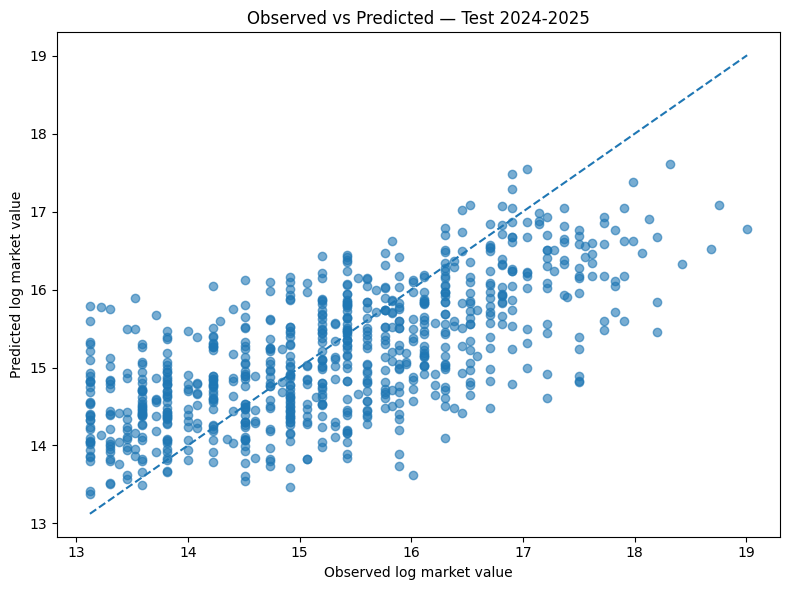

In [18]:
# Observado vs predicho en test
plt.figure(figsize=(8, 6))
plt.scatter(test_scored[TARGET], test_scored["predicted_log_market_value"], alpha=0.6)
min_val = min(test_scored[TARGET].min(), test_scored["predicted_log_market_value"].min())
max_val = max(test_scored[TARGET].max(), test_scored["predicted_log_market_value"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Observed log market value")
plt.ylabel("Predicted log market value")
plt.title("Observed vs Predicted — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_observed_vs_predicted_test.png", dpi=150)
plt.show()

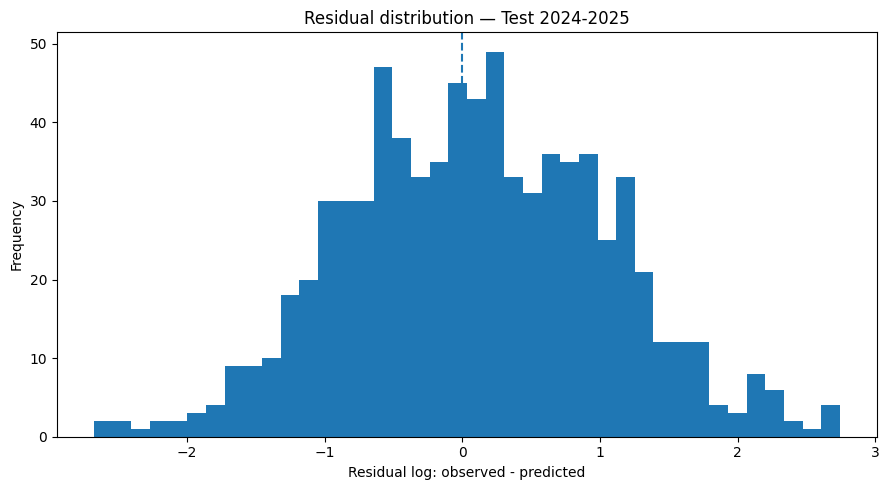

In [19]:
# Distribución de residuos en test
plt.figure(figsize=(9, 5))
plt.hist(test_scored["residual_log_observed_minus_predicted"], bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual log: observed - predicted")
plt.ylabel("Frequency")
plt.title("Residual distribution — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_residual_distribution_test.png", dpi=150)
plt.show()

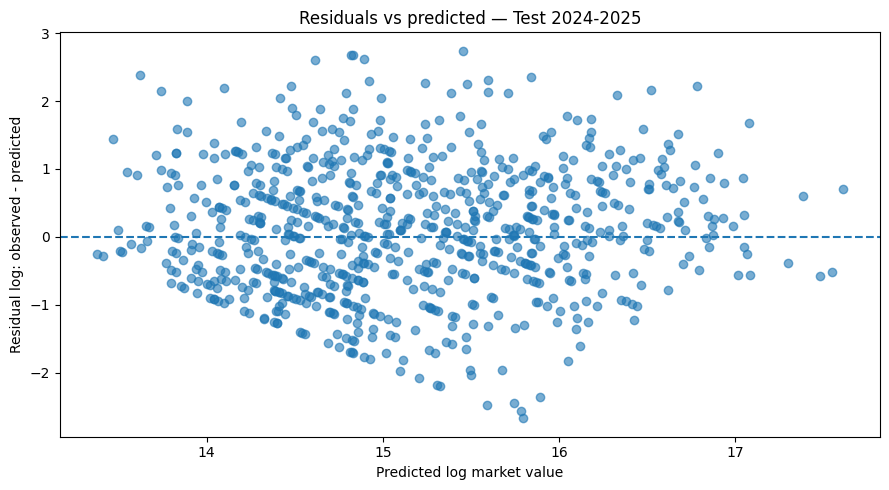

In [20]:
# Residuos vs predicción en test
plt.figure(figsize=(9, 5))
plt.scatter(test_scored["predicted_log_market_value"], test_scored["residual_log_observed_minus_predicted"], alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log market value")
plt.ylabel("Residual log: observed - predicted")
plt.title("Residuals vs predicted — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_residuals_vs_predicted_test.png", dpi=150)
plt.show()

## 12. Inefficiency Score final

El Inefficiency Score se define como:

```text
valor estimado - valor observado
```

En este notebook se calcula sobre el test histórico para evaluar si el modelo econométrico genera señales razonables de infravaloración.

En la arquitectura actual del proyecto, el scoring operativo incorpora además:

- Growth Score;
- Confidence Score;
- Opportunity Score;
- Risk Score;
- Risk-adjusted Opportunity Score.

Por tanto, el score de este notebook debe interpretarse como antecedente metodológico del Scoring Engine completo.


In [21]:
# ============================================================
# 12. Rankings sobre test out-of-sample
# ============================================================

test_scored_final = scored[scored["split"] == "test"].copy()

ranking_cols = [c for c in [
    "player_id_tm", "player_id", "player_name", "club", "current_club_name_tm",
    "league", "season", "position_group", "age", "minutes_played",
    "market_value_eur", "predicted_market_value_eur",
    "market_value_gap_eur", "market_value_gap_pct",
    "log_market_value_eur", "predicted_log_market_value",
    "inefficiency_score", "inefficiency_score_z",
    "confidence_score", "opportunity_score",
    "matching_method", "matching_confidence", "age_diff", "club_score",
] if c in test_scored_final.columns]

undervalued_ranking = (
    test_scored_final
    .query("inefficiency_score > 0")
    .sort_values(["opportunity_score", "market_value_gap_eur"], ascending=False)
    [ranking_cols]
    .head(50)
    .copy()
)

overvalued_ranking = (
    test_scored_final
    .query("inefficiency_score < 0")
    .sort_values(["opportunity_score", "market_value_gap_eur"], ascending=True)
    [ranking_cols]
    .head(50)
    .copy()
)

undervalued_ranking.to_csv(OUTPUT_DIR / "03_undervalued_ranking.csv", index=False)
overvalued_ranking.to_csv(OUTPUT_DIR / "03_overvalued_ranking.csv", index=False)

display(undervalued_ranking.head(20))

,player_id_tm,player_name,club,current_club_name_tm,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,log_market_value_eur,predicted_log_market_value,inefficiency_score,inefficiency_score_z,confidence_score,opportunity_score,matching_method,matching_confidence,age_diff,club_score
3856,"512,352.0000",Lasse Rosenboom,Holstein Kiel,Holstein Kiel,Bundesliga,2024-2025,MID,22.9185,1734,"500,000.0000","7,245,532.1851","6,745,532.1851",13.4911,13.1224,15.7959,2.6735,2.7378,1.0000,2.7378,exact_age_club_validated,1.0000,0.9185,100.0000
4267,"610,608.0000",Dominik Javorček,Holstein Kiel,"SK Slavia Praha, a.s.",Bundesliga,2024-2025,DEF,22.1328,386,"550,000.0000","7,150,800.8998","6,600,800.8998",12.0015,13.2177,15.7827,2.5651,2.6267,0.8500,2.2327,exact_age_validated,0.8500,1.1328,31.2500
4467,"948,273.0000",Mario Martín,Valladolid,Getafe Club de Fútbol S. A. D. Team Dubai,LaLiga,2024-2025,MID,20.6023,1748,"500,000.0000","5,909,337.7905","5,409,337.7905",10.8187,13.1224,15.5920,2.4697,2.5291,0.8500,2.1497,exact_age_validated,0.8500,0.6023,20.8333
4163,"1,390,649.0000",Yan Diomandé,Leganés,RasenBallsport Leipzig,LaLiga,2024-2025,MID,18.4723,545,"600,000.0000","6,885,212.7578","6,285,212.7578",10.4754,13.3047,15.7449,2.4402,2.4989,0.8500,2.1240,exact_age_validated,0.8500,1.4723,41.3793
3999,"927,353.0000",Johan Manzambi,Freiburg,Sport-Club Freiburg,Bundesliga,2024-2025,MID,18.9870,335,"750,000.0000","7,987,991.5488","7,237,991.5488",9.6507,13.5278,15.8934,2.3656,2.4225,0.8500,2.0591,exact_age_validated,0.8500,0.9870,59.2593
4497,"877,139.0000",Alberto costa,Juventus,Futebol Clube do Porto,Serie A,2024-2025,DEF,21.0267,357,"500,000.0000","4,519,954.9600","4,019,954.9600",8.0399,13.1224,15.3240,2.2016,2.2546,0.8500,1.9164,exact_age_validated,0.8500,1.0267,20.0000
4244,"807,688.0000",Yassin Belkhdim,Angers,Angers Sporting Club de l'Ouest,Ligue 1,2024-2025,MID,22.6448,1523,"500,000.0000","4,442,236.5693","3,942,236.5693",7.8845,13.1224,15.3067,2.1843,2.2368,0.8500,1.9013,exact_age_validated,0.8500,0.6448,32.4324
4099,"1,061,336.0000",Pau Navarro,Villarreal,Villarreal Club de Fútbol S.A.D.,LaLiga,2024-2025,DEF,19.6496,916,"500,000.0000","4,018,677.1744","3,518,677.1744",7.0374,13.1224,15.2065,2.0841,2.1342,0.8500,1.8141,exact_age_validated,0.8500,0.6496,48.7805
4510,"1,190,411.0000",Jesus Rodríguez,Real Betis,Calcio Como,LaLiga,2024-2025,MID,18.8966,1111,"700,000.0000","5,392,655.4722","4,692,655.4722",6.7038,13.4588,15.5005,2.0417,2.0908,0.8500,1.7772,exact_age_validated,0.8500,0.8966,19.0476
4258,"743,496.0000",Kévin Danois,Auxerre,Association de la Jeunesse auxerroise,Ligue 1,2024-2025,MID,20.2765,1460,"500,000.0000","3,605,590.3005","3,105,590.3005",6.2112,13.1224,15.0980,1.9756,2.0231,0.8500,1.7197,exact_age_validated,0.8500,0.2765,31.8182


In [22]:
print("Top overvalued players — test")
display(overvalued_ranking.head(20))

Top overvalued players — test


,player_id_tm,player_name,club,current_club_name_tm,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,log_market_value_eur,predicted_log_market_value,inefficiency_score,inefficiency_score_z,confidence_score,opportunity_score,matching_method,matching_confidence,age_diff,club_score
3987,"646,740.0000",Gavi,Barcelona,Futbol Club Barcelona,LaLiga,2024-2025,MID,20.3943,1085,"80,000,000.0000","5,154,113.8965","-74,845,886.1035",-0.9356,18.1975,15.4553,-2.7422,-2.8082,0.8500,-2.3869,exact_age_validated,0.8500,1.3943,60.0000
3896,"810,092.0000",Warren Zaïre-Emery,Paris Saint-Germain,Paris Saint-Germain Football Club,Ligue 1,2024-2025,DEF,18.7598,2050,"60,000,000.0000","5,951,347.1179","-54,048,652.8821",-0.9008,17.9099,15.5991,-2.3107,-2.3663,1.0000,-2.3663,exact_age_club_validated,1.0000,0.7598,73.0769
4564,"565,424.0000",Johan Bakayoko,PSV,RasenBallsport Leipzig,Eredivisie,2024-2025,MID,21.6619,1579,"40,000,000.0000","2,731,596.5390","-37,268,403.4610",-0.9317,17.5044,14.8204,-2.6840,-2.7485,0.8500,-2.3362,exact_age_validated,0.8500,0.6619,16.0000
4104,"650,568.0000",António Silva,Benfica,Sport Lisboa e Benfica,Liga Portugal,2024-2025,DEF,20.9418,2037,"40,000,000.0000","2,758,586.0848","-37,241,413.9152",-0.9310,17.5044,14.8302,-2.6742,-2.7385,0.8500,-2.3277,exact_age_validated,0.8500,0.9418,48.2759
3877,"792,380.0000",Aleksandar Pavlovic,Bayern Munich,FC Bayern München,Bundesliga,2024-2025,MID,20.4353,1451,"50,000,000.0000","5,280,924.6420","-44,719,075.3580",-0.8944,17.7275,15.4796,-2.2479,-2.3020,1.0000,-2.3020,exact_age_club_validated,1.0000,0.4353,80.0000
3989,"974,982.0000",Ousmane Diomande,Sporting CP,Sporting Clube de Portugal,Liga Portugal,2024-2025,DEF,21.0431,2521,"40,000,000.0000","2,929,578.4671","-37,070,421.5329",-0.9268,17.5044,14.8904,-2.6140,-2.6769,0.8500,-2.2753,exact_age_validated,0.8500,1.0431,59.4595
4615,"473,169.0000",Brian Brobbey,Ajax,Sunderland Association Football Club,Eredivisie,2024-2025,ATT,22.8747,1555,"30,000,000.0000","2,221,194.5920","-27,778,805.4080",-0.9260,17.2167,14.6136,-2.6032,-2.6657,0.8500,-2.2659,exact_age_validated,0.8500,0.8747,10.0000
3876,"580,195.0000",Jamal Musiala,Bayern Munich,FC Bayern München,Bundesliga,2024-2025,MID,21.3908,1798,"130,000,000.0000","14,963,440.9392","-115,036,559.0608",-0.8849,18.6830,16.5211,-2.1619,-2.2139,1.0000,-2.2139,exact_age_club_validated,1.0000,0.3908,80.0000
3895,"661,171.0000",Willian Pacho,Paris Saint-Germain,Paris Saint-Germain Football Club,Ligue 1,2024-2025,DEF,22.9760,2132,"40,000,000.0000","4,814,896.5166","-35,185,103.4834",-0.8796,17.5044,15.3872,-2.1172,-2.1681,1.0000,-2.1681,exact_age_club_validated,1.0000,0.9760,73.0769
3900,"616,341.0000",Nuno Mendes,Paris Saint-Germain,Paris Saint-Germain Football Club,Ligue 1,2024-2025,DEF,22.4778,1676,"55,000,000.0000","6,649,978.9642","-48,350,021.0358",-0.8791,17.8228,15.7101,-2.1127,-2.1635,1.0000,-2.1635,exact_age_club_validated,1.0000,0.4778,73.0769


## 13. Análisis agregado del score

El análisis agregado permite comprobar si las señales de ineficiencia presentan patrones coherentes por:

- liga;
- posición;
- nivel de confianza;
- valor de mercado.

Estas lecturas son útiles para diagnóstico econométrico, pero no reemplazan la capa operativa de ranking introducida posteriormente.


In [23]:
# Asegurar que el subset de test incluye todas las columnas de scoring
test_scored_final = scored[scored["split"] == "test"].copy()

# Inefficiency por liga en test
league_score = (
    test_scored_final
    .groupby("league", dropna=False)
    .agg(
        n=("inefficiency_score", "size"),
        mean_inefficiency=("inefficiency_score", "mean"),
        median_inefficiency=("inefficiency_score", "median"),
        mean_gap_eur=("market_value_gap_eur", "mean"),
        median_gap_eur=("market_value_gap_eur", "median"),
        mean_gap_pct=("market_value_gap_pct", "mean"),
        mean_confidence=("confidence_score", "mean"),
        mean_opportunity=("opportunity_score", "mean"),
    )
    .reset_index()
    .sort_values("mean_inefficiency", ascending=False)
)

display(league_score)

league_score.to_csv(
    OUTPUT_DIR / "03_inefficiency_by_league_test.csv",
    index=False
)

,league,n,mean_inefficiency,median_inefficiency,mean_gap_eur,median_gap_eur,mean_gap_pct,mean_confidence,mean_opportunity
10,Spanish Segunda División,20,0.2550,0.1838,"108,072.4720","149,864.1875",0.6809,0.8500,0.2219
5,LaLiga,72,0.1025,0.2197,"-7,952,794.9795","1,023,645.1925",0.9809,0.8604,0.0923
9,Serie A,77,-0.0049,-0.0201,"-2,216,781.7974","-139,150.5022",0.4623,0.8539,-0.0042
6,Liga Portugal,60,-0.0569,0.0915,"-2,572,512.9595","186,938.2042",0.4610,0.8525,-0.0490
2,Bundesliga,77,-0.0980,-0.1836,"-7,995,465.8210","-1,735,332.0321",0.6216,0.8792,-0.0881
1,Belgian Pro League,111,-0.1130,-0.1466,"-905,251.2399","-218,774.7229",0.1465,0.8527,-0.0971
0,Austrian Bundesliga,48,-0.1251,0.1302,"-1,747,241.8068","119,277.9462",0.3315,0.8531,-0.1069
7,Ligue 1,99,-0.1280,-0.1386,"-5,031,709.9767","-1,035,084.8894",0.4535,0.8682,-0.1260
4,Eredivisie,93,-0.1489,-0.0963,"-2,271,938.4660","-73,442.6982",0.2904,0.8629,-0.1211
3,Championship,45,-0.2700,-0.3579,"-2,387,761.6987","-857,313.6477",0.2369,0.8533,-0.2327


In [24]:
# Re-crear subsets después de calcular todos los scores
train_scored = scored[scored["split"] == "train"].copy()
test_scored = scored[scored["split"] == "test"].copy()

required_scoring_cols = [
    "inefficiency_score",
    "inefficiency_score_z",
    "confidence_score",
    "opportunity_score",
]

missing_cols = [c for c in required_scoring_cols if c not in test_scored.columns]

if missing_cols:
    raise KeyError(f"Missing scoring columns in test_scored: {missing_cols}")

print("Scoring subsets actualizados correctamente")
print(f"Train scored: {train_scored.shape}")
print(f"Test scored: {test_scored.shape}")

Scoring subsets actualizados correctamente
Train scored: (3854, 92)
Test scored: (776, 92)


## 14. Robustness check con matching estricto

Este robustness check evalúa si los resultados son sensibles a la calidad del matching.

Se restringe la muestra a observaciones con mayor confianza de integración.

Interpretación:

- si la muestra estricta mantiene resultados similares, aumenta la confianza metodológica;
- si mejora sustancialmente, puede indicar que el ruido de matching penaliza el modelo;
- si empeora, puede reflejar pérdida de cobertura o sesgo de selección.

En Sprint 10, esta lógica se complementa con Confidence Score y Risk Score dentro de la Current Scouting Layer.


In [25]:
# ============================================================
# 13. Robustness check: matching estricto
# ============================================================

strict_df = model_df.copy()

if "matching_confidence" in strict_df.columns:
    strict_df = strict_df[pd.to_numeric(strict_df["matching_confidence"], errors="coerce") >= 0.99]

if "age_diff" in strict_df.columns:
    strict_df = strict_df[pd.to_numeric(strict_df["age_diff"], errors="coerce") <= 1.0]

if "matching_method" in strict_df.columns:
    strict_df = strict_df[strict_df["matching_method"].isin([
        "exact_age_validated",
        "exact_age_club_validated",
        "fuzzy_age_club_validated",
    ])]

strict_train = strict_df[strict_df["season"].isin(TRAIN_SEASONS)].copy()
strict_test = strict_df[strict_df["season"] == TEST_SEASON].copy()

print(f"Strict rows: {len(strict_df):,}")
print(f"Strict train rows: {len(strict_train):,}")
print(f"Strict test rows: {len(strict_test):,}")

if len(strict_train) >= 50 and len(strict_test) >= 20:
    strict_model, X_strict_train = fit_ols_hc3(strict_train, final_numeric_features, final_categorical_features)
    strict_pred_test = predict_with_design(strict_model, strict_test, X_strict_train, final_numeric_features, final_categorical_features)
    strict_metrics = pd.DataFrame([
        regression_metrics(strict_test[TARGET], strict_pred_test, "M3_strict_matching", "test")
    ])
    display(strict_metrics)
    strict_metrics.to_csv(OUTPUT_DIR / "03_strict_matching_metrics.csv", index=False)
else:
    print("Muestra estricta demasiado pequeña para estimar un modelo robusto comparable.")


Strict rows: 244
Strict train rows: 146
Strict test rows: 44


,model,split,n,MAE_log,RMSE_log,R2
0,M3_strict_matching,test,44,0.8445,1.0914,0.5274


## 15. Conclusiones para la memoria del TFM

Este notebook consolida la reestimación econométrica de Sprint 13B tras la integración de nuevas métricas avanzadas de FBref.

La contribución metodológica principal consiste en evaluar si una representación más rica del rendimiento futbolístico mejora la explicación del valor de mercado esperado.

La comparación se realiza entre:

```text
Modelo A
Especificación v13A
```

y

```text
Modelo B
Especificación v13A
+
finishing_index_v2
+
availability_index
+
defensive_activity_index
```

La interpretación final debe basarse en:

- variación de R² y R² ajustado;
- MAE y RMSE out-of-sample;
- AIC y BIC;
- significancia estadística de las nuevas variables;
- VIF de las nuevas variables;
- coherencia económica de los signos estimados.

Sprint 13B no solo busca mejorar métricas predictivas, sino evaluar si las nuevas features aportan una representación más equilibrada entre rendimiento ofensivo, disponibilidad competitiva y actividad defensiva.

## 16. Próximos pasos

Tras la reestimación econométrica Sprint 13B, los siguientes pasos son:

### 1. Evaluación de resultados econométricos

Analizar:

- `ols_model_comparison.csv`;
- `03_advanced_feature_coefficients.csv`;
- `vif_model_b.csv`;
- `correlation_advanced_features.csv`.

El objetivo es decidir si las nuevas features deben pasar a la capa de Machine Learning.

---

### 2. Machine Learning Re-estimation

Reentrenar los modelos supervisados sobre:

```text
player_season_modeling_v13b_advanced.parquet
```

comparando contra v13A:

- Random Forest;
- HistGradientBoosting;
- LightGBM;
- XGBoost.

---

### 3. Scouting Intelligence Upgrade

Si las nuevas features resultan útiles, incorporarlas a:

- radar charts;
- benchmarking posicional;
- explicación de recomendaciones;
- narrativa de scouting.

---

### 4. Documentación Sprint 13B

Actualizar:

- `feature_engineering_plan.md`;
- `modeling_decisions.md`;
- `data_dictionary.md`;
- `pipeline_reference.md`;
- `memoria_metodologica_notas.md`.